## 0. 목표

1. SSD 모델을 활용하여 

2. 개와 고양이의 얼굴 영역을 감지한다.

### 기본 설정

In [65]:
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc
import os


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda:0") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


# 로그
import logging

def init_logger() -> logging.Logger:
    logging.basicConfig(
        format="%(asctime)s [%(levelname)s] (%(filename)s:%(lineno)d) - %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
        level=logging.INFO,
        encoding="utf-8",
    )
    return logging.getLogger("")

logger = init_logger()

2025-11-27 22:32:31 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/Apple Color Emoji.ttc: Could not set the fontsize (invalid pixel size; error code 0x17)
2025-11-27 22:32:31 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: Can not load face (locations (loca) table missing; error code 0x90)
2025-11-27 22:32:31 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: Could not set the fontsize (invalid pixel size; error code 0x17)
2025-11-27 22:32:31 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/SFIndia.ttc: Can not load face (SFNT font table missing; error code 0x8e)
2025-11-27 22:32:31 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be inte

## 1. 데이터 확인

### 레이블 데이터

In [66]:
# 딕셔너리 반환 함수 생성
def get_label_dict(txt_file):
    global info_list

    f = open(txt_file, "r")
    lines = f.readlines()

    # \n 제거
    info_list = []
    for line in lines:
        info_list.append(line.strip())

    label_dict = dict()
    for item in info_list:
        label_dict[item.split(" ")[0]] = {
                                        "class_id": item.split(" ")[1],
                                        "species": item.split(" ")[2],
                                        "breed_id": item.split(" ")[3]
                                        }
    return label_dict


train_label_dict = get_label_dict("./data/annotations/annotations/trainval.txt")
test_label_dict = get_label_dict("./data/annotations/annotations/test.txt")


print(f"[레이블 개수]")
print(f"· 총 {len(train_label_dict) + len(test_label_dict)}개")
print(f"· Train : {len(train_label_dict)}개")
print(f"· Test : {len(test_label_dict)}개")

print(f"\n[레이블 샘플 출력]")
print(f"· {train_label_dict}")

[레이블 개수]
· 총 7349개
· Train : 3680개
· Test : 3669개

[레이블 샘플 출력]
· {'Abyssinian_100': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_101': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_102': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_103': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_104': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_105': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_106': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_107': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_108': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_109': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_10': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_110': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_111': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_112': {'class

- 레이블 중에서 고양이(1)/개(2)를 가리키는 species만 사용한다.

### 이미지 데이터

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


[이미지 데이터]
· 파일: 7390개
· 최대 H: 2606 | 최대 W: 3264 | 최소 H: 103 | 최소 W: 114


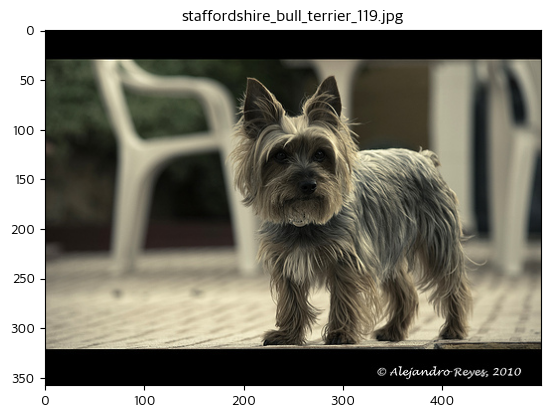

In [67]:
import random
import glob
import torchvision
from PIL import Image

images_path = sorted(glob.glob("./data/images/images/*.jpg"))

rand_idx = random.randint(0, len(images_path))

file_name = images_path[rand_idx].split("/")[-1]


h_min, w_min = 100000, 100000
h_max, w_max = 0, 0

for img in images_path:
    img = torchvision.io.read_image(img).permute(1, 2, 0)

    h_max = max(h_max, img.shape[0])
    w_max = max(w_max, img.shape[1])
    h_min = min(h_min, img.shape[0])
    w_min = min(w_min, img.shape[1])

print(f"[이미지 데이터]")
print(f"· 파일: {len(images_path)}개")
print(f"· 최대 H: {h_max} | 최대 W: {w_max} | 최소 H: {h_min} | 최소 W: {w_min}")

plt.imshow(img)
plt.title(f"{file_name}")
plt.show()

귀엽군

- 이미지 사이즈의 편차가 심하다.

In [68]:
# for i, path in enumerate(images_path):
#     print(f"\rChecking [{i}]: {os.path.basename(path)}", end="")
#     img = torchvision.io.read_image(path).permute(1, 2, 0)

# err_list = ["beagle_15.jpg", "chihuahua_99.jpg", "beagle_2.jpg", "english_cocker_spaniel_118.jpg", "chihuahua_93.jpg", "beagle_39.jpg", "beagle_76.jpg", "english_cocker_spaniel_145.jpg"]

# for err in err_list:
#     images_path.remove(f"./data/images/images/{err}")

# for i, path in enumerate(images_path):
#     print(f"\rChecking [{i}]: {os.path.basename(path)}", end="")
#     img = torchvision.io.read_image(path).permute(1, 2, 0)

### 좌표 데이터

In [69]:
import xml.etree.ElementTree as ET

annots_path = sorted(glob.glob("./data/annotations/annotations/xmls/*.xml"))

print(f"[좌표 데이터]")
print(f"· 좌표 개수: {len(annots_path)}개")


# xml 하위 요소 출력 함수 생성
def crawl_xml(mom, count=0):
    for child in mom:
        if child.text == None:
            print(f"· {child.tag}")
            crawl_xml(child, count+1)
        else:
            space = count * "  "
            print(f"{space}· {child.tag}: {child.text}")


# 샘플 xml 출력
rand_idx = random.randint(0, len(annots_path))

with open(annots_path[rand_idx]) as f:
    tree = ET.parse(f)
    root = tree.getroot()

print("\n[xml 샘플 출력]")
crawl_xml(root)

[좌표 데이터]
· 좌표 개수: 3686개

[xml 샘플 출력]
· folder: OXIIIT
· filename: shiba_inu_156.jpg
· source
  · database: OXFORD-IIIT Pet Dataset
  · annotation: OXIIIT
  · image: flickr
· size
  · width: 333
  · height: 500
  · depth: 3
· segmented: 0
· object
  · name: dog
  · pose: Frontal
  · truncated: 0
  · occluded: 0
· bndbox
    · xmin: 40
    · ymin: 96
    · xmax: 305
    · ymax: 374
  · difficult: 0


- bbox는 xyxy 형태이다.

In [70]:
# bbox 추출 함수 생성
def get_bbox(file):
    with open(file) as f:
        tree = ET.parse(f)
        root = tree.getroot()
    
    for obj in root.findall('object'):      
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
            
    return [xmin, ymin, xmax, ymax]

# 샘플 bbox 출력
rand_idx = random.randint(0, len(annots_path))
get_bbox(annots_path[rand_idx])

[135, 28, 379, 246]

[복수 객체 파일]
· 개수: 1개
· 목록: ['Bengal_105']

[xml 출력]
(파일명: ./data/annotations/annotations/xmls/Bengal_105.xml)
· folder: OXIIIT
· filename: Bengal_105.jpg
· source
  · database: OXFORD-IIIT Pet Dataset
  · annotation: OXIIIT
  · image: flickr
· size
  · width: 500
  · height: 466
  · depth: 3
· segmented: 0
· object
  · name: cat
  · pose: Frontal
  · truncated: 0
  · occluded: 0
· bndbox
    · xmin: 49
    · ymin: 125
    · xmax: 111
    · ymax: 168
  · difficult: 0
· object
  · name: cat
  · pose: Frontal
  · truncated: 0
  · occluded: 0
· bndbox
    · xmin: 397
    · ymin: 103
    · xmax: 451
    · ymax: 132
  · difficult: 0


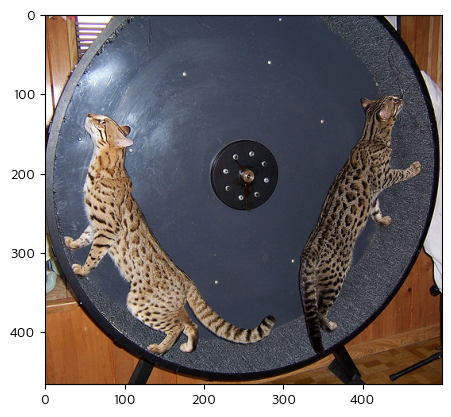

In [71]:
# 복수 객체 이미지 검출

multi_object_count = 0
multi_object_names = []
multi_object_xmls = []

for path in annots_path:
    with open(path) as f:
        tree = ET.parse(f)
        root = tree.getroot()
    
    objects = root.findall('object')
    num_objects = len(objects)
    
    if num_objects > 1:
        multi_object_count += 1
        multi_object_names.append(path.split('/')[-1].split(".")[0])
        multi_object_xmls.append(path)

print(f"[복수 객체 파일]")
print(f"· 개수: {len(multi_object_names)}개")

if len(multi_object_names) > 0:
    print(f"· 목록: {multi_object_names}")
    print(f"\n[xml 출력]")
    for xml in multi_object_xmls:
        print(f"(파일명: {xml})")
        with open(xml) as f:
            tree = ET.parse(f)
            root = tree.getroot()
        crawl_xml(root)


    for name in multi_object_names:
        img = Image.open(f"./data/images/images/{name}.jpg").convert("RGB")

        plt.imshow(img)
        plt.show()

In [72]:
# 객체 없는 이미지 검출

no_object_count = 0
no_object_names = []
no_object_xmls = []

for path in annots_path:
    with open(path) as f:
        tree = ET.parse(f)
        root = tree.getroot()
    
    objects = root.findall('object')
    num_objects = len(objects)
    
    if num_objects == 0:
        no_object_count += 1
        no_object_names.append(path.split('/')[-1].split(".")[0])
        no_object_xmls.append(path)

print(f"[객체 없는 파일]")
print(f"· 개수: {len(no_object_names)}개")

if len(no_object_names) > 0:
    print(f"· 목록: {no_object_names}")
    print(f"\n[xml 출력]")
    for xml in no_object_xmls:
        print(f"(파일명: {xml})")
        with open(xml) as f:
            tree = ET.parse(f)
            root = tree.getroot()
        crawl_xml(root)


    for name in no_object_names:
        img = Image.open(f"./data/images/images/{name}.jpg").convert("RGB")

        plt.imshow(img)
        plt.show()

[객체 없는 파일]
· 개수: 0개


객체 없는 데이터는 없다.

레이블 데이터만 train/test로 분류되어 있으므로, 

이를 기준으로 이미지와 좌표 데이터를 분류하고 오류를 확인한다.

또한, 이미지·레이블·좌표 데이터의 개수가 각각 달랐기 때문에 점검이 필요하다.

### 분류 작업

In [73]:
import os 

train_label_set = set(train_label_dict.keys())
test_label_set = set(test_label_dict.keys())

tmp_image_list = os.listdir("./data/images/images/")
tmp_annot_list = os.listdir("./data/annotations/annotations/xmls/")

all_image_set = set()
all_annot_set = set()

for file_name in tmp_image_list:
    all_image_set.add(file_name.split(".")[0].strip())

for file_name in tmp_annot_list:
    all_annot_set.add(file_name.split(".")[0].strip())

train_image_set = all_image_set & all_annot_set & train_label_set
test_image_set = all_image_set & all_annot_set & test_label_set

train_annot_set = train_image_set & all_annot_set & train_label_set
test_annot_set = test_image_set & (all_annot_set - train_annot_set) & test_label_set

### 오류 확인

In [74]:
print(f"[train 데이터 오류 확인]")

warning, blank = "<--", ""
I, L, A = train_image_set, train_label_set, train_annot_set

print(f"· 이미지 O | label X | 좌표 X: {len(I - L - A)}개 {warning if len(I - L - A) != 0 else blank}")
print(f"· 이미지 O | label O | 좌표 X: {len((I & L) - A)}개 {warning if len((I & L) - A) != 0 else blank}")
print(f"· 이미지 O | label X | 좌표 O: {len((I & A) - L)}개 {warning if len((I & A) - L) != 0 else blank}")
print(f"· 이미지 O | label O | 좌표 O: {len(I & L & A)}개 {warning if len(I & L & A) == 0 else blank}")
print(f"· 이미지 X | label O | 좌표 O: {len((A & L) - I)}개 {warning if len((A & L) - I) != 0 else blank}")
print(f"· 이미지 X | label O | 좌표 X: {len(L - I - A)}개 {warning if len(L - I - A) != 0 else blank}")
print(f"· 이미지 X | label X | 좌표 O: {len(A - I - L)}개 {warning if len(A - I - L) != 0 else blank}")


print(f"\n[test 데이터 오류 확인]")

I, L, A = test_image_set, test_label_set, test_annot_set

print(f"· 이미지 O | label X | 좌표 X: {len(I - L - A)}개 {warning if len(I - L - A) != 0 else blank}")
print(f"· 이미지 O | label O | 좌표 X: {len((I & L) - A)}개 {warning if len((I & L) - A) != 0 else blank}")
print(f"· 이미지 O | label X | 좌표 O: {len((I & A) - L)}개 {warning if len((I & A) - L) != 0 else blank}")
print(f"· 이미지 O | label O | 좌표 O: {len(I & L & A)}개 {warning if len(I & L & A) == 0 else blank}")
print(f"· 이미지 X | label O | 좌표 O: {len((A & L) - I)}개 {warning if len((A & L) - I) != 0 else blank}")
print(f"· 이미지 X | label O | 좌표 X: {len(L - I - A)}개 {warning if len(L - I - A) != 0 else blank}")
print(f"· 이미지 X | label X | 좌표 O: {len(A - I - L)}개 {warning if len(A - I - L) != 0 else blank}")

[train 데이터 오류 확인]
· 이미지 O | label X | 좌표 X: 0개 
· 이미지 O | label O | 좌표 X: 0개 
· 이미지 O | label X | 좌표 O: 0개 
· 이미지 O | label O | 좌표 O: 3671개 
· 이미지 X | label O | 좌표 O: 0개 
· 이미지 X | label O | 좌표 X: 9개 <--
· 이미지 X | label X | 좌표 O: 0개 

[test 데이터 오류 확인]
· 이미지 O | label X | 좌표 X: 0개 
· 이미지 O | label O | 좌표 X: 0개 
· 이미지 O | label X | 좌표 O: 0개 
· 이미지 O | label O | 좌표 O: 0개 <--
· 이미지 X | label O | 좌표 O: 0개 
· 이미지 X | label O | 좌표 X: 3669개 <--
· 이미지 X | label X | 좌표 O: 0개 


[학습 데이터]

- 좌표가 할당되지 않은 학습 데이터(9개)

    이는 테스트 데이터로 이용하거나 일절 이용하지 않아야 한다.

    테스트 데이터의 개수는 충분하므로, 사용하지 않는 방향으로 진행한다.

    이미지, 레이블, 좌표 데이터를 모두 가지고 있는 리스트를 통해 학습 데이터를 설정한다.

- 복수 객체 데이터(1개)

    오류는 아니지만, 1개에 불과하다는 점에서 학습 시간과 함수 효율성을 고려하여 제외한다.

[테스트 데이터]

- 테스트 데이터는 객체 레이블까지만 제공한다. 즉, 학습 과정의 테스트 데이터가 아니라 실제 테스트 데이터이다.

    테스트 데이터를 이용한 평가는 시각화를 통해 판단해야 한다.

    IOU, mAP 등은 학습 과정에서만 진행해야 한다.

In [75]:
# 학습 데이터 최종 설정

train_name_list = sorted(list(train_image_set & train_label_set & train_annot_set))
del_name_list = sorted(list(train_label_set - train_image_set - train_annot_set))
del_name_list.extend(multi_object_names) # 복수 객체 파일 제외

for i in del_name_list:
    if i in train_name_list:
        train_name_list.remove(i)

TRAIN_IMAGE_LIST = []
TRAIN_ANNOT_LIST = []
TRAIN_LABEL_LIST = []

for name in train_name_list:
    TRAIN_IMAGE_LIST.append(f"./data/images/images/{name}.jpg")
    TRAIN_ANNOT_LIST.append(f"./data/annotations/annotations/xmls/{name}.xml")
    TRAIN_LABEL_LIST.append(int(train_label_dict[name]["species"])) # 클래스 인덱스 변경(cat: 0, dog: 1)


In [76]:
print(f"[클래스별 개수]")

total_count = len(TRAIN_LABEL_LIST)

dog_count = sum(TRAIN_LABEL_LIST) - total_count
cat_count = total_count - dog_count

NUM_CLASSES = 3 # 고양이/개/배경

print(f"· 총 {total_count}개")
print(f"· cat: {cat_count}개 ({cat_count/total_count*100:.2f}%)")
print(f"· dog: {dog_count}개 ({dog_count/total_count*100:.2f}%)")

[클래스별 개수]
· 총 3670개
· cat: 1180개 (32.15%)
· dog: 2490개 (67.85%)


클래스의 불균형이 존재하므로, 비율에 맞춰 학습 데이터와 검증 데이터를 설정해야 한다.

In [77]:
print(f"[데이터 분할]")

from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.transforms import Normalize, Resize

# 데이터셋 설정
from torch.utils.data import Dataset
from torchvision.transforms import v2

DEFAULT_TRANSFORM = v2.Compose([
                v2.ToImage(),
                v2.ToDtype(dtype=torch.float32, scale=True),
                # 증강 추가하기
                ])


class CatDogDataset(Dataset):
    def __init__(self):
        self.images = TRAIN_IMAGE_LIST
        self.boxes = TRAIN_ANNOT_LIST
        self.labels = TRAIN_LABEL_LIST
        self.transform = DEFAULT_TRANSFORM

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = Image.open(self.images[index]).convert("RGB")
        box = get_bbox(self.boxes[index])
        label = self.labels[index]

        image = self.transform(image)
        target = {"boxes": torch.tensor([box], dtype=torch.float32),
                  "labels": torch.tensor([label], dtype=torch.int64)
                  }
        
        return image, target
    
    
trainval_dataset = CatDogDataset()


# 데이터 분할(학습과 검증 데이터에서 클래스 비율 유지)
from sklearn.model_selection import train_test_split

train_indices, val_indices = train_test_split(
    list(range(len(trainval_dataset))),
    test_size=0.2,
    stratify=[label for label in trainval_dataset.labels]
)


print(f"· Train: {len(train_indices)}개 ({len(train_indices)/len(trainval_dataset)*100:.2f}%)")
print(f"· Val: {len(val_indices)}개 ({len(val_indices)/len(trainval_dataset)*100:.2f}%)")

[데이터 분할]
· Train: 2936개 (80.00%)
· Val: 734개 (20.00%)


In [78]:
# 데이터 로더 설정
from torch.utils.data import Subset, DataLoader

train_subset = Subset(trainval_dataset, train_indices)
val_subset = Subset(trainval_dataset, val_indices)

TRAIN_DATALOADER = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=0, collate_fn=lambda x: tuple(zip(*x)))
VAL_DATALOADER = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=0, collate_fn=lambda x: tuple(zip(*x)))

## 2. 실험 설계

1. 모델

    미션에서 주어진 SSD 모델로 진행한다.

    이미 91개의 클래스가 학습된 상태이므로, 클래스 개수 등의 조정이 필요하다.

    - 특징맵에 대한 가중치는 그대로 두고 클래스 수만 맞추도록 마지막 레이어만 수정한다.

    - 샘플 이미지를 레이어별로 출력하여 필요 레이블부터 수정한다.

    - backbone의 가중치는 그대로 두고 나머지는 가져오지 않는다.

In [79]:
# # 모델, optimizer 설정
# import torchvision
# from torchvision.models.detection.ssd import SSD300_VGG16_Weights

# DEFAULT_MODEL = torchvision.models.detection.ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT).to(DEVICE)

# OPTIM = torch.optim.SGD(DEFAULT_MODEL.parameters(), lr=0.005)
# # OPTIM = torch.optim.SGD(DEFAULT_MODEL.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

### 기본 SSD 모델 파악

In [80]:
import torchvision
from torchvision.models.detection.ssd import ssd300_vgg16, SSD300_VGG16_Weights

DEFAULT_MODEL = torchvision.models.detection.ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)

layers_dict = dict(DEFAULT_MODEL.named_children())

print(layers_dict.keys())
print(layers_dict["head"])
print(layers_dict["backbone"])
print(layers_dict["transform"])

dict_keys(['backbone', 'anchor_generator', 'head', 'transform'])
SSDHead(
  (classification_head): SSDClassificationHead(
    (module_list): ModuleList(
      (0): Conv2d(512, 364, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(1024, 546, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): Conv2d(512, 546, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): Conv2d(256, 546, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4-5): 2 x Conv2d(256, 364, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (regression_head): SSDRegressionHead(
    (module_list): ModuleList(
      (0): Conv2d(512, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(1024, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): Conv2d(512, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): Conv2d(256, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4-5): 2 x Conv2d(256, 16, kernel_size=(3, 3)

- Backbone: 이미지에서 특징을 뽑는 VGG나 ResNet 부분

- Head: 뒤쪽에 추가로 붙어서 피라미드 구조를 만드는 층 (클래스 수와 관련)

    -   (classification_head): SSDClassificationHead에서 클래스 수를 수정해야 한다.


In [96]:
model = ssd300_vgg16(weights=None, num_classes=NUM_CLASSES)

model.backbone.load_state_dict(DEFAULT_MODEL.backbone.state_dict())

clean_cache()

model = model.to(DEVICE)
optim = torch.optim.SGD(
    model.parameters(), 
    lr=0.001,           # 학습률
    momentum=0.9,       # 모멘텀
    weight_decay=0.0005 # L2 정규화
)

layers_dict = dict(model.named_children())

print(layers_dict["head"])

SSDHead(
  (classification_head): SSDClassificationHead(
    (module_list): ModuleList(
      (0): Conv2d(512, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(1024, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): Conv2d(512, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): Conv2d(256, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4-5): 2 x Conv2d(256, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (regression_head): SSDRegressionHead(
    (module_list): ModuleList(
      (0): Conv2d(512, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(1024, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): Conv2d(512, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): Conv2d(256, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4-5): 2 x Conv2d(256, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
)


In [82]:
# for i, layer in enumerate(model.head.classification_head.module_list):
    
#     current_num_anchors = layer.out_channels // 91

#     new_out_channels = current_num_anchors * NUM_CLASSES

#     model.head.classification_head.module_list[i] = nn.Conv2d(
#         in_channels=layer.in_channels,
#         out_channels=new_out_channels,
#         kernel_size=layer.kernel_size,
#         stride=layer.stride,
#         padding=layer.padding
#     )

# model.head.classification_head.num_classes = NUM_CLASSES

# layers_dict = dict(model.named_children())
# print(layers_dict["head"].classification_head)

# # 옵티마이저 설정 (기존 코드 유지)
# params = [p for p in model.parameters() if p.requires_grad]
# OPTIM = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

In [ ]:
# from torchmetrics.detection.mean_ap import MeanAveragePrecision

# print("=" * 60)
# print("모델 평가 (학습 전 - 성능 확인용)")
# print("=" * 60)

# # mAP 계산 설정
# metric = MeanAveragePrecision(
#     class_metrics=True,  # 클래스별 메트릭 계산
#     max_detection_thresholds=[1, 10, 100]
#     )

# model.eval()  # 평가 모드

# print("\n평가 시작...")
# print("⚠️  학습 전이므로 성능이 매우 낮을 것입니다.\n")

# with torch.no_grad():
#     for batch_idx, (images, targets) in enumerate(TRAIN_DATALOADER):
#         # 데이터를 디바이스로 이동
#         images = list(image.to(DEVICE) for image in images)
#         targets = [{key: value.to(DEVICE) for key, value in t.items()} 
#                    for t in targets]
        
#         # 추론
#         predictions = model(images)
        
#         # 메트릭 업데이트
#         metric.update(predictions, targets)
        
#         # 진행상황 출력
#         if (batch_idx + 1) % 5 == 0:
#             print(f"  진행: {batch_idx + 1}/{len(TRAIN_DATALOADER)} 배치")
        
#         # 테스트용으로 일부만 평가 (선택사항)
#         if batch_idx >= 9:  # 처음 10개 배치만
#             print(f"  (샘플 평가: 10개 배치만 사용)")
#             break

# # 결과 계산
# results = metric.compute()

# print("\n" + "=" * 60)
# print("평가 결과:")
# print("=" * 60)

# # 전체 메트릭 (스칼라)
# print("\n[전체 평가 메트릭]")
# scalar_metrics = ['map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large',
#                   'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large']

# for key in scalar_metrics:
#     if key in results:
#         value = results[key]
#         if torch.is_tensor(value):
#             print(f"  {key:12s}: {value.item():.4f}")
#         else:
#             print(f"  {key:12s}: {value:.4f}")

# # 클래스별 메트릭 (텐서)
# print("\n[클래스별 평가 메트릭]")
# print("  클래스: [배경, 고양이, 강아지]\n")

# class_metrics = ['map_per_class', 'mar_100_per_class']
# class_names = ['배경', '고양이', '강아지']

# for key in class_metrics:
#     if key in results:
#         value = results[key]
#         if torch.is_tensor(value):
#             print(f"  {key}:")
#             for i, (class_name, class_value) in enumerate(zip(class_names, value)):
#                 if class_value == -1:
#                     print(f"    {class_name}: N/A (데이터 없음)")
#                 else:
#                     print(f"    {class_name}: {class_value:.4f}")
#         else:
#             print(f"  {key}: {value}")

# # 기타 메트릭 출력
# print("\n[기타 메트릭]")
# for key, value in results.items():
#     if key not in scalar_metrics and key not in class_metrics:
#         if torch.is_tensor(value):
#             if value.numel() == 1:
#                 print(f"  {key}: {value.item():.4f}")
#             else:
#                 print(f"  {key}: {value.tolist()}")
#         else:
#             print(f"  {key}: {value}")

# # 메모리 정리
# del predictions, images, targets
# clean_cache()

# print("\n" + "=" * 60)


모델 평가 (학습 전 - 성능 확인용)

평가 시작...
⚠️  학습 전이므로 성능이 매우 낮을 것입니다.



/Users/won/dev/codeit/.venv/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


  진행: 5/46 배치
  진행: 10/46 배치
  (샘플 평가: 10개 배치만 사용)

평가 결과:

[전체 평가 메트릭]
  map         : 0.0018
  map_50      : 0.0099
  map_75      : 0.0002
  map_small   : -1.0000
  map_medium  : 0.0003
  map_large   : 0.0023
  mar_1       : 0.0224
  mar_10      : 0.0621
  mar_100     : 0.1457
  mar_small   : -1.0000
  mar_medium  : 0.0733
  mar_large   : 0.1616

[클래스별 평가 메트릭]
  클래스: [배경, 고양이, 강아지]

  map_per_class:
    배경: 0.0008
    고양이: 0.0028
  mar_100_per_class:
    배경: 0.1376
    고양이: 0.1538

[기타 메트릭]
  classes: [1, 2]



In [84]:
# from torchmetrics.detection.mean_ap import MeanAveragePrecision

# metric = MeanAveragePrecision(max_detection_thresholds=[1, 10, 100])

# model.to(DEVICE)

# model.eval()
# num_epoch = 1

# for i in range(num_epoch):
#     with torch.no_grad():
#             for images, targets in TRAIN_DATALOADER:
#                 images = list(image.to(DEVICE) for image in images)
#                 targets = [{key: value.to(DEVICE) for key, value in targets_key.items()} for targets_key in targets]
#                 predictions = model(images)

#                 metric.update(predictions, targets)


# results = metric.compute()
# print(results)

In [85]:
# num_epochs = 5
# for epoch in range(num_epochs):
#     model.train()  # 학습 모드 전환
#     epoch_loss = 0
    
#     for images, targets in TRAIN_DATALOADER:
#         # 데이터 디바이스로 이동
#         images = list(image.to(DEVICE) for image in images)
#         targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
#         # 순전파 (Forward): 학습 모드에서는 손실 딕셔너리 반환
#         loss_dict = model(images, targets)
        
#         # 총 손실 계산 (분류 손실 + 회귀 손실)
#         losses = sum(loss for loss in loss_dict.values())
        
#         # 역전파 및 가중치 업데이트
#         OPTIM.zero_grad()
#         losses.backward()
#         OPTIM.step()
        
#         epoch_loss += losses.item()

#         print(losses)
        
#     print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(TRAIN_DATALOADER):.4f}")

2. 손실

    - 좌표 손실: IOU

    - 레이블 손실: mAP

In [86]:
# import numpy as np

# x1, y1, x2, y2 = 0, 0, 0, 0
# x1_pred, y1_pred, x2_pred, y2_pred = 0, 0, 0, 0

# x1_pred, x2_pred = min(x1_pred, x2_pred), max(x1_pred, x2_pred)
# y1_pred, y2_pred = min(y1_pred, y2_pred), max(y1_pred, y2_pred)

# def get_IOU(list, pred_list):
#     x1, y1, x2, y2 = list[0], list[1], list[2], list[3]
#     x1_pred, y1_pred, x2_pred, y2_pred = pred_list[0], pred_list[1], pred_list[2], pred_list[3]
#     if (x2_pred <= x1) or (y2_pred <= y1):
#         return 0
#     else:
#         rectangle = (x2 - x1) * (y2 - y1)
#         rectangle_pred = (x2_pred - x1_pred) * (y2_pred - y1_pred)
#         intersection = (x2_pred - x1) * (y2_pred - y1)
#         iou = intersection / (rectangle + rectangle_pred - intersection)
#         return  iou

In [94]:
import torch
import numpy as np

def calculate_iou(box1, box2):
    """
    두 바운딩 박스 간의 IoU 계산
    
    Args:
        box1, box2: [x1, y1, x2, y2] 형태의 박스 (텐서 또는 넘파이 배열)
    
    Returns:
        IoU 값 (float)
    """
    # 텐서를 넘파이로 변환
    if torch.is_tensor(box1):
        box1 = box1.cpu().numpy()
    if torch.is_tensor(box2):
        box2 = box2.cpu().numpy()
    
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    
    # 교집합 영역 계산
    x_left = max(x1_1, x1_2)
    y_top = max(y1_1, y1_2)
    x_right = min(x2_1, x2_2)
    y_bottom = min(y2_1, y2_2)
    
    # 교집합이 없는 경우
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    
    intersection = (x_right - x_left) * (y_bottom - y_top)
    
    # 합집합 영역 계산
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
    union = box1_area + box2_area - intersection
    
    iou = intersection / union if union > 0 else 0.0
    return iou


def calculate_batch_iou(predictions, targets):
    """
    배치 전체의 평균 IoU 계산
    
    Args:
        predictions: 모델의 예측 결과 (list of dict)
        targets: 정답 타겟 (list of dict)
    
    Returns:
        평균 IoU 값
    """
    total_iou = 0.0
    count = 0
    
    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes'].cpu()
        pred_scores = pred['scores'].cpu()
        pred_labels = pred['labels'].cpu()
        target_boxes = target['boxes'].cpu()
        target_labels = target['labels'].cpu()
        
        # 각 타겟 박스에 대해 가장 높은 IoU를 가진 예측 찾기
        for t_box, t_label in zip(target_boxes, target_labels):
            max_iou = 0.0
            
            # 같은 클래스의 예측만 고려
            for p_box, p_label, p_score in zip(pred_boxes, pred_labels, pred_scores):
                if p_label == t_label and p_score > 0.5:  # 임계값 0.5
                    iou = calculate_iou(t_box, p_box)
                    max_iou = max(max_iou, iou)
            
            total_iou += max_iou
            count += 1
    
    return total_iou / count if count > 0 else 0.0

In [95]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def train_one_epoch(model, optimizer, dataloader, device, epoch):
    """
    1 에포크 학습
    
    Returns:
        평균 손실값
    """
    model.train()
    total_loss = 0.0
    num_batches = len(dataloader)
    
    for batch_idx, (images, targets) in enumerate(dataloader):
        # 데이터를 디바이스로 이동
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Forward pass (학습 모드에서는 loss_dict 반환)
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        # 손실 누적
        total_loss += losses.item()
        
        # 진행상황 출력 (10 배치마다)
        if (batch_idx + 1) % 10 == 0:
            avg_loss = total_loss / (batch_idx + 1)
            print(f"  [{epoch}] 배치 {batch_idx + 1}/{num_batches} | "
                  f"Loss: {losses.item():.4f} | Avg Loss: {avg_loss:.4f}")
    
    return total_loss / num_batches


def validate(model, dataloader, device, epoch, compute_map=True):
    """
    검증 수행
    
    Args:
        compute_map: mAP 계산 여부 (False면 IoU만 계산, 속도 향상)
    
    Returns:
        평균 손실, 평균 IoU, mAP 결과
    """
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    num_batches = 0
    
    # mAP 계산용
    if compute_map:
        metric = MeanAveragePrecision(
            class_metrics=False,  # 속도를 위해 클래스별 메트릭 비활성화
            max_detection_thresholds=[1, 10, 100]
        )
    
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(dataloader):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # 손실 계산 (학습 모드로 일시 전환)
            model.train()
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            total_loss += losses.item()
            
            # 예측 수행 (평가 모드)
            model.eval()
            predictions = model(images)
            
            # IoU 계산
            batch_iou = calculate_batch_iou(predictions, targets)
            total_iou += batch_iou
            
            # mAP 계산
            if compute_map:
                metric.update(predictions, targets)
            
            num_batches += 1
            
            # 진행상황 출력
            if (batch_idx + 1) % 5 == 0:
                print(f"  [Val {epoch}] 배치 {batch_idx + 1}/{len(dataloader)} | "
                      f"IoU: {batch_iou:.4f}")
    
    avg_loss = total_loss / num_batches
    avg_iou = total_iou / num_batches
    
    map_results = metric.compute() if compute_map else None
    
    return avg_loss, avg_iou, map_results

In [97]:
import time
from datetime import datetime

NUM_EPOCHS = 5
EVAL_MAP_EVERY = 1  # 5 에포크마다 mAP 계산 (속도 고려)

# 학습 기록 저장
history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_map': [],
    'val_map_50': [],
    'epochs_with_map': []  # mAP를 계산한 에포크 번호
}

best_map = 0.0
best_epoch = 0

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    
    # 학습
    train_loss = train_one_epoch(model, optim, TRAIN_DATALOADER, DEVICE, epoch)
    
    # 검증 (mAP는 주기적으로만 계산)
    compute_map = (epoch % EVAL_MAP_EVERY == 0) or (epoch == NUM_EPOCHS)
    val_loss, val_iou, map_results = validate(
        model, VAL_DATALOADER, DEVICE, epoch, compute_map=compute_map
    )
    
    # 기록 저장
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    
    # 에포크 소요 시간
    epoch_time = time.time() - epoch_start
    
    # 결과 출력
    print(f"\n{'─'*70}")
    print(f"Epoch {epoch} 완료 (소요시간: {epoch_time:.1f}초)")
    print(f"{'─'*70}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss  : {val_loss:.4f}")
    print(f"  Val IoU   : {val_iou:.4f}")
    
    # mAP 결과 출력
    if compute_map and map_results is not None:
        map_value = map_results['map'].item()
        map_50 = map_results['map_50'].item()
        
        history['val_map'].append(map_value)
        history['val_map_50'].append(map_50)
        history['epochs_with_map'].append(epoch)
        
        print(f"  Val mAP   : {map_value:.4f}")
        
        # 최고 성능 모델 저장
        if map_value > best_map:
            best_map = map_value
            best_epoch = epoch
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optim.state_dict(),
                'map': map_value,
                'map_50': map_50,
                'iou': val_iou
            }, './best_model.pth')
    
    # 메모리 정리
    clean_cache()

Epoch 1/5
  [1] 배치 10/46 | Loss: 7.7057 | Avg Loss: 10.2174
  [1] 배치 20/46 | Loss: 7.1614 | Avg Loss: 8.6801
  [1] 배치 30/46 | Loss: 6.5732 | Avg Loss: 8.0703
  [1] 배치 40/46 | Loss: 6.3435 | Avg Loss: 7.6545
  [Val 1] 배치 5/12 | IoU: 0.0000
  [Val 1] 배치 10/12 | IoU: 0.0000

──────────────────────────────────────────────────────────────────────
Epoch 1 완료 (소요시간: 601.1초)
──────────────────────────────────────────────────────────────────────
  Train Loss: 7.4602
  Val Loss  : 5.9296
  Val IoU   : 0.0000
  Val mAP   : 0.0092
Epoch 2/5
  [2] 배치 10/46 | Loss: 5.5708 | Avg Loss: 5.7748
  [2] 배치 20/46 | Loss: 5.3898 | Avg Loss: 5.6679
  [2] 배치 30/46 | Loss: 5.1135 | Avg Loss: 5.5534
  [2] 배치 40/46 | Loss: 5.0885 | Avg Loss: 5.4835
  [Val 2] 배치 5/12 | IoU: 0.0000
  [Val 2] 배치 10/12 | IoU: 0.0000

──────────────────────────────────────────────────────────────────────
Epoch 2 완료 (소요시간: 562.1초)
──────────────────────────────────────────────────────────────────────
  Train Loss: 5.4429
  Val Loss  : 

/var/folders/h6/_8g_zbns4n53222bttvjsx_40000gn/T/ipykernel_15794/4243145637.py:63: RuntimeWarning: divide by zero encountered in scalar divide
  • IoU 증가 : {(history['val_iou'][-1] / history['val_iou'][0] - 1) * 100:.1f}%
/var/folders/h6/_8g_zbns4n53222bttvjsx_40000gn/T/ipykernel_15794/4243145637.py:71: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/h6/_8g_zbns4n53222bttvjsx_40000gn/T/ipykernel_15794/4243145637.py:71: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/h6/_8g_zbns4n53222bttvjsx_40000gn/T/ipykernel_15794/4243145637.py:71: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/h6/_8g_zbns4n53222bttvjsx_40000gn/T/ipykernel_15794/4243145637.py:71: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/fol

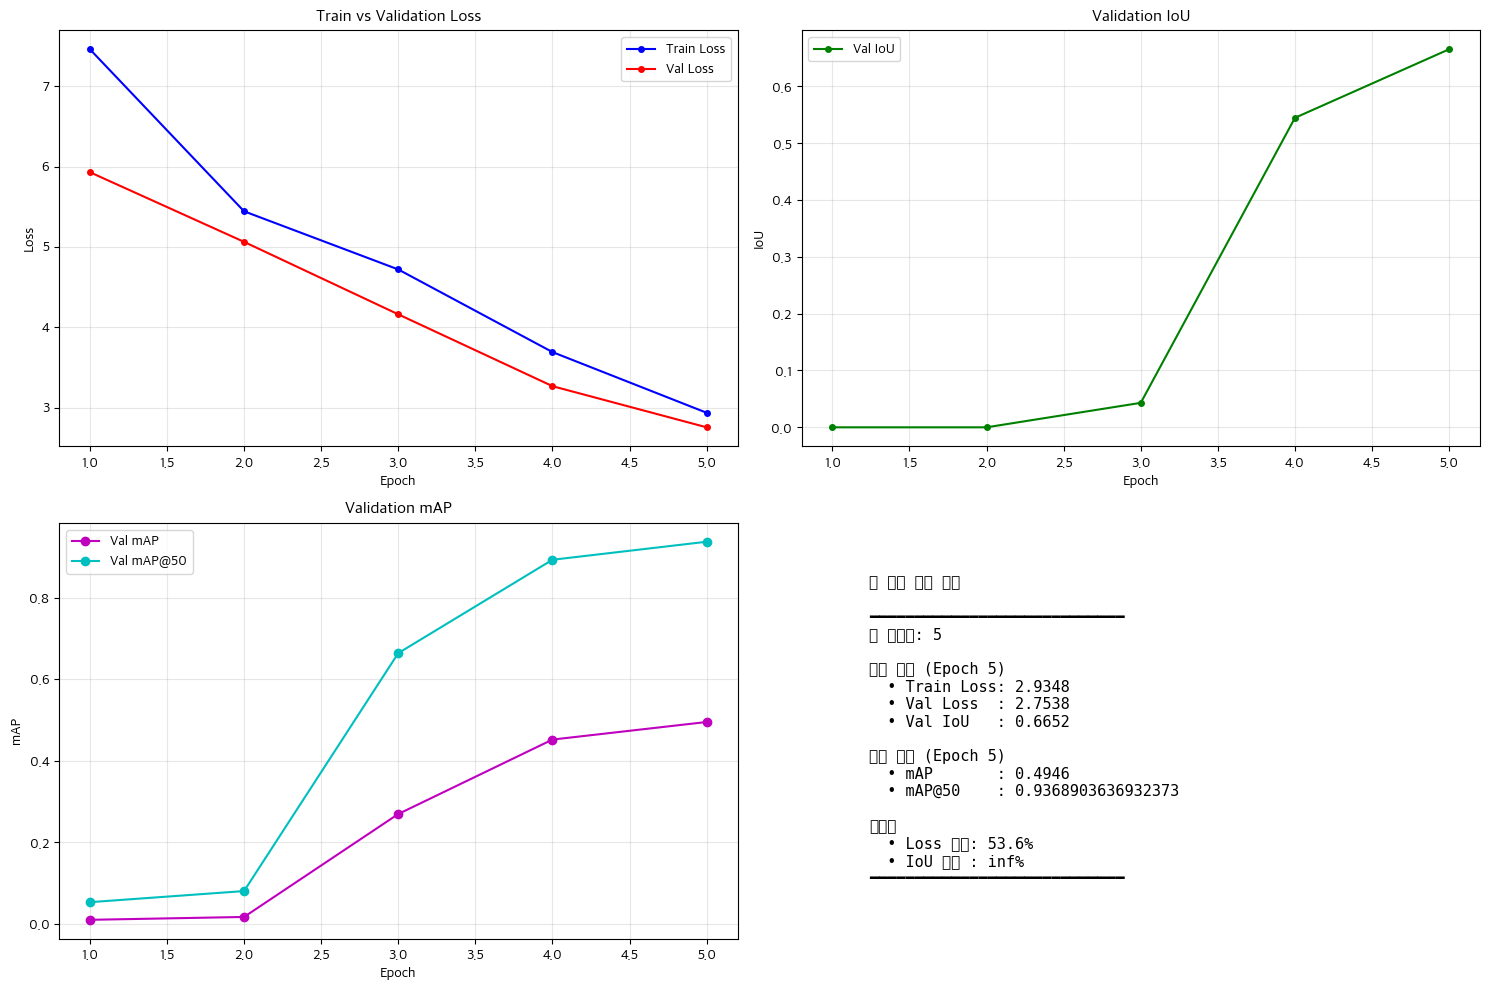

In [98]:
import matplotlib.pyplot as plt

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 학습 곡선 시각화
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs = range(1, len(history['train_loss']) + 1)

# 1. 손실 그래프
axes[0, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Train vs Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. IoU 그래프
axes[0, 1].plot(epochs, history['val_iou'], 'g-o', label='Val IoU', markersize=4)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('IoU')
axes[0, 1].set_title('Validation IoU')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. mAP 그래프
if history['val_map']:
    axes[1, 0].plot(history['epochs_with_map'], history['val_map'], 
                    'm-o', label='Val mAP', markersize=6)
    axes[1, 0].plot(history['epochs_with_map'], history['val_map_50'], 
                    'c-o', label='Val mAP@50', markersize=6)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mAP')
    axes[1, 0].set_title('Validation mAP')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'mAP 데이터 없음', 
                    ha='center', va='center', fontsize=12)
    axes[1, 0].set_title('Validation mAP')

# 4. 종합 성능 지표
axes[1, 1].axis('off')
summary_text = f"""
📊 학습 결과 요약

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
총 에포크: {NUM_EPOCHS}

최종 성능 (Epoch {NUM_EPOCHS})
  • Train Loss: {history['train_loss'][-1]:.4f}
  • Val Loss  : {history['val_loss'][-1]:.4f}
  • Val IoU   : {history['val_iou'][-1]:.4f}

최고 성능 (Epoch {best_epoch})
  • mAP       : {best_map:.4f}
  • mAP@50    : {history['val_map_50'][history['epochs_with_map'].index(best_epoch)] if best_epoch in history['epochs_with_map'] else 'N/A'}

개선도
  • Loss 감소: {(1 - history['val_loss'][-1] / history['val_loss'][0]) * 100:.1f}%
  • IoU 증가 : {(history['val_iou'][-1] / history['val_iou'][0] - 1) * 100:.1f}%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

axes[1, 1].text(0.1, 0.5, summary_text, 
                fontsize=11, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('./training_history.png', dpi=150, bbox_inches='tight')
plt.show()

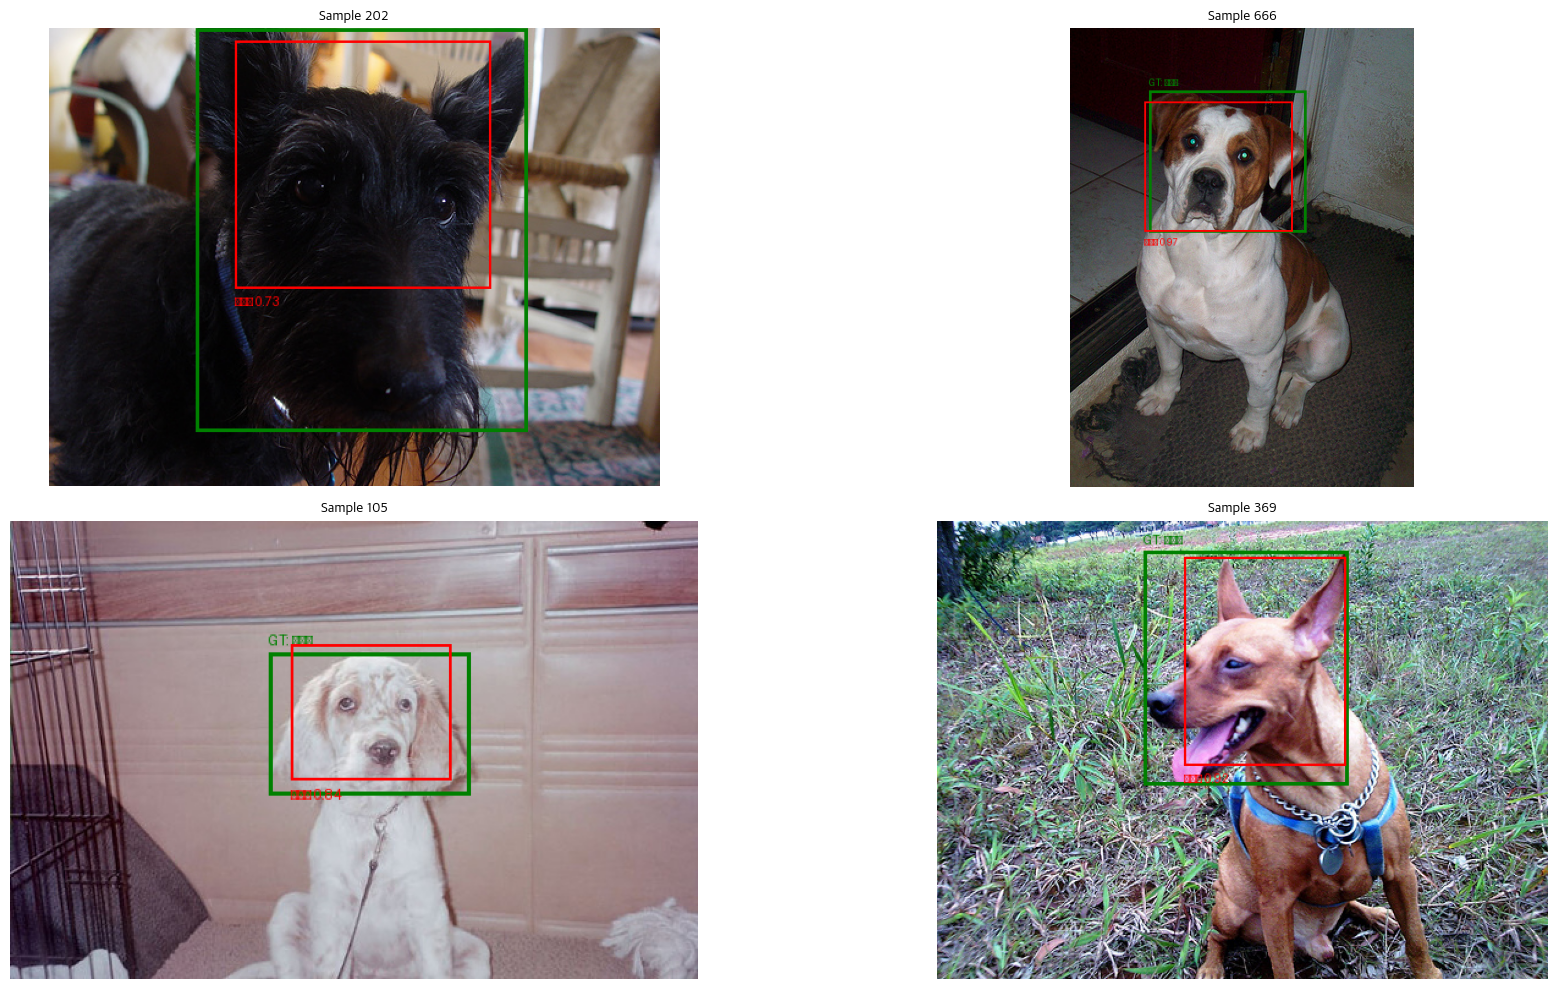

✅ 예측 결과 시각화 완료 (./predictions.png 저장됨)
   • 초록색: Ground Truth (정답)
   • 파란색: 고양이 예측
   • 빨간색: 강아지 예측


In [ ]:
import random
from PIL import Image, ImageDraw, ImageFont

def visualize_predictions(model, dataset, device, num_samples=4, confidence_threshold=0.5):
    """
    모델의 예측 결과를 시각화
    
    Args:
        model: 학습된 모델
        dataset: 데이터셋
        num_samples: 시각화할 샘플 개수
        confidence_threshold: 신뢰도 임계값
    """
    model.eval()
    
    # 클래스명과 색상 정의
    class_names = {0: '배경', 1: '고양이', 2: '강아지'}
    colors = {0: 'gray', 1: 'blue', 2: 'red'}
    
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(20, 10))
    axes = axes.flatten()
    
    # 랜덤 샘플 선택
    indices = random.sample(range(len(dataset)), num_samples)
    
    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            # 데이터 로드
            image, target = dataset[idx]
            image_tensor = image.to(device)
            
            # 예측
            prediction = model([image_tensor])[0]
            
            # 이미지를 PIL로 변환 (시각화용)
            img_pil = Image.fromarray(
                (image.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            )
            draw = ImageDraw.Draw(img_pil)
            
            # 정답 박스 그리기 (초록색)
            for box, label in zip(target['boxes'], target['labels']):
                x1, y1, x2, y2 = box.cpu().numpy()
                draw.rectangle([x1, y1, x2, y2], outline='green', width=3)
                draw.text((x1, y1 - 15), f'GT: {class_names[label.item()]}', 
                         fill='green')
            
            # 예측 박스 그리기
            for box, label, score in zip(prediction['boxes'], 
                                          prediction['labels'], 
                                          prediction['scores']):
                if score > confidence_threshold:
                    x1, y1, x2, y2 = box.cpu().numpy()
                    color = colors[label.item()]
                    draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
                    draw.text((x1, y2 + 5), 
                             f'{class_names[label.item()]} {score:.2f}', 
                             fill=color)
            
            # 이미지 표시
            ax.imshow(img_pil)
            ax.axis('off')
            ax.set_title(f'Sample {idx}', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('./predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    

# 검증 데이터셋에서 시각화
visualize_predictions(model, val_subset, DEVICE, num_samples=4, confidence_threshold=0.5)


In [100]:
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optim.state_dict(),
    'history': history,
    'best_epoch': best_epoch,
    'best_map': best_map
}, './final_model.pth')

def load_best_model(model_path='./best_model.pth'):
    """최고 성능 모델 불러오기"""
    checkpoint = torch.load(model_path, map_location=DEVICE)
    
    # 모델 재생성
    loaded_model = ssd300_vgg16(weights=None, num_classes=NUM_CLASSES)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model = loaded_model.to(DEVICE)
    loaded_model.eval()
    
    print(f"✅ 모델 불러오기 완료")
    print(f"   • Epoch: {checkpoint['epoch']}")
    print(f"   • mAP: {checkpoint['map']:.4f}")
    print(f"   • mAP@50: {checkpoint['map_50']:.4f}")
    print(f"   • IoU: {checkpoint['iou']:.4f}")
    
    return loaded_model